# W1 - Statistical Analysis: Olist Payment & Delivery Data

## D1: Descriptive Statistics & Distributions
- Dataset: olist_raw.order_payments (103,886 records)
- Key finding: Payment value is heavily right-skewed (skewness=9.25)
- Mean (154 BRL) overstates typical order value by 54% vs median (100 BRL)
- Log transformation normalises distribution — essential before ML modelling

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

conn = psycopg2.connect(
    host="olist-pipeline.cg1gusiqwbyb.us-east-1.rds.amazonaws.com",
    port=5432,
    database="postgres",
    user="postgres",
    password="Admin1234!"
)

# Verify connection + check available tables
query = """
    SELECT table_schema, table_name 
    FROM information_schema.tables 
    WHERE table_schema NOT IN ('information_schema', 'pg_catalog')
    ORDER BY table_schema, table_name
"""

df_tables = pd.read_sql(query, conn)
print(df_tables)

C:\Users\deepe\AppData\Local\Temp\ipykernel_14804\2677839359.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql(query, conn)


   table_schema                    table_name
0    crypto_dev                     dim_coins
1    crypto_dev              fct_daily_prices
2    crypto_dev          fct_market_dominance
3    crypto_dev           fct_volume_analysis
4    crypto_dev               stg_coin_prices
5    crypto_raw                  daily_prices
6     olist_dev                 dim_customers
7     olist_dev                      dim_date
8     olist_dev                  dim_products
9     olist_dev   fct_bad_reviews_by_category
10    olist_dev      fct_category_performance
11    olist_dev                    fct_orders
12    olist_dev          fct_payment_analysis
13    olist_dev               stg_order_items
14    olist_dev            stg_order_payments
15    olist_dev             stg_order_reviews
16    olist_dev                    stg_orders
17    olist_dev                  stg_products
18    olist_raw                     customers
19    olist_raw                   geolocation
20    olist_raw                   

In [13]:
import sys
print(sys.executable)

c:\Python\python.exe


In [14]:
# Pull payment data for distribution analysis
df_payments = pd.read_sql("""
    SELECT order_id, payment_type, payment_value
    FROM olist_raw.order_payments
""", conn)

# Pull orders data for delivery analysis later
df_orders = pd.read_sql("""
    SELECT order_id, order_status,
           order_purchase_timestamp,
           order_delivered_customer_date,
           order_estimated_delivery_date
    FROM olist_raw.orders
    WHERE order_status = 'delivered'
""", conn)

print("Payments shape:", df_payments.shape)
print("Orders shape:", df_orders.shape)
print(df_payments.head())

C:\Users\deepe\AppData\Local\Temp\ipykernel_14804\2387124533.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_payments = pd.read_sql("""
C:\Users\deepe\AppData\Local\Temp\ipykernel_14804\2387124533.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orders = pd.read_sql("""


Payments shape: (103886, 3)
Orders shape: (96478, 5)
                           order_id payment_type  payment_value
0  b81ef226f3fe1789b1e8b2acac839d17  credit_card          99.33
1  a9810da82917af2d9aefd1278f1dcfa0  credit_card          24.39
2  25e8ea4e93396b6fa0d3dd708e76c1bd  credit_card          65.71
3  ba78997921bbcdc1373bb41e913ab953  credit_card         107.78
4  42fdf880ba16b47b59251dd489d4441a  credit_card         128.45


In [15]:
print("=== Payment Value Stats ===")
print(df_payments['payment_value'].describe())
print(f"\nSkewness: {df_payments['payment_value'].skew():.3f}")
print(f"Kurtosis: {df_payments['payment_value'].kurtosis():.3f}")
print(f"Missing Values: {df_payments['payment_value'].isnull().sum()}")

=== Payment Value Stats ===
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Skewness: 9.254
Kurtosis: 241.828
Missing Values: 0


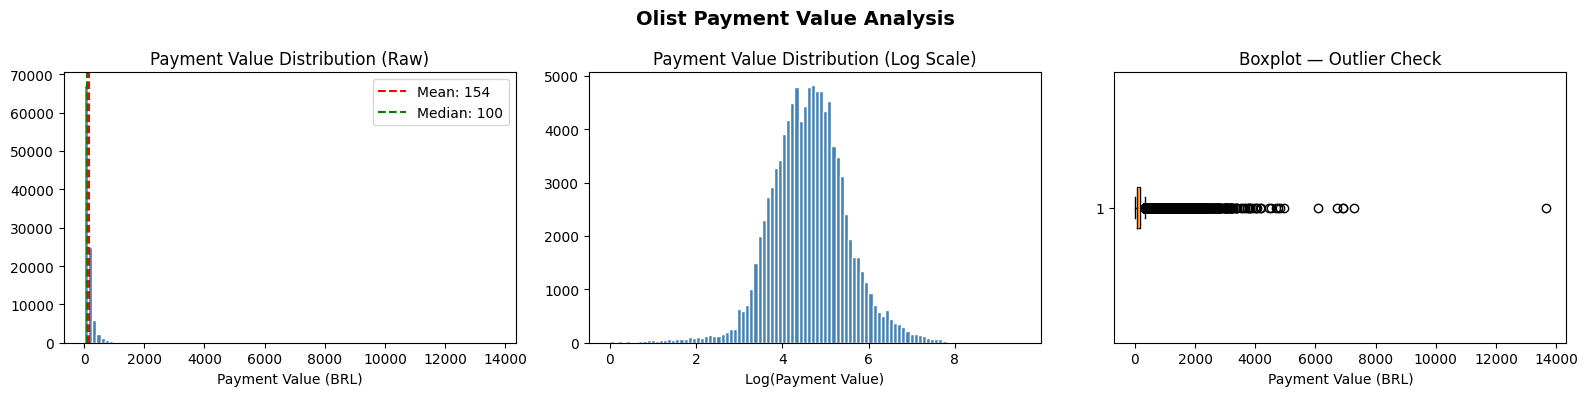

In [16]:
fig, axes = plt.subplots(1,3, figsize= (16, 4))

axes[0].hist(df_payments['payment_value'], bins = 100, color = 'steelblue', edgecolor = 'white')
axes[0].set_title('Payment Value Distribution (Raw)')
axes[0].set_xlabel('Payment Value (BRL)')
axes[0].axvline(df_payments['payment_value'].mean(), color='red', linestyle='--', label=f"Mean: {df_payments['payment_value'].mean():.0f}")
axes[0].axvline(df_payments['payment_value'].median(), color='green', linestyle='--', label=f"Median: {df_payments['payment_value'].median():.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df_payments['payment_value']), bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Payment Value Distribution (Log Scale)')
axes[1].set_xlabel('Log(Payment Value)')

axes[2].boxplot(df_payments['payment_value'], vert=False)
axes[2].set_title('Boxplot — Outlier Check')
axes[2].set_xlabel('Payment Value (BRL)')

plt.suptitle('Olist Payment Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('payment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()